## MINI-PROJEKT 3 - klasyfikator obrazów

* Wczytanie danych treningowych 
* Augmentacja danych
* Custom Dataset dla zbioru testowego - tenor + nazwa pliku
* Generowanie pliku preds.csv, zapis wszystkiego do zipa i wyslanie



* Budowa architektury CNN
* Pętla ucząca 
* Tuning hiperparametrów

In [1]:
import os
import random
from pprint import pprint

import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchmetrics

In [2]:
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.use_deterministic_algorithms(True)

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # wymagane przez niektóre operacje CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
device

device(type='mps')

### 1. Wczytanie danych treningowych & augmentacja

In [3]:
IMG_SIZE = 128 
BATCH_SIZE = 256

# transformacja dla treningowego (z augmentacja)
train_transform = transforms.Compose([
    # transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5), # losowe odbicie lustrzane
    transforms.RandomRotation(degrees=15),  # losowy obrot o max 15 stopni
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # zmiana kolorkow o max 20%
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # normalizacja
])


try:
    trainset = ImageFolder(root="train/", transform=train_transform)
    map_class_to_idx = trainset.class_to_idx
    print(f"Loaded train dataset: {len(trainset)} images, {len(trainset.classes)} classes.")
    pprint(f"Mapped classes: {map_class_to_idx}")
except FileNotFoundError:
    print("Couldnt fing 'train/' directory!!!!")

Loaded train dataset: 88011 images, 50 classes.
("Mapped classes: {'acoustic': 0, 'antenna': 1, 'bacteria': 2, 'battery': 3, "
 "'bean': 4, 'beetle': 5, 'bicycle': 6, 'birch': 7, 'bird': 8, 'bomb': 9, "
 "'bread': 10, 'bridge': 11, 'camera': 12, 'carbon': 13, 'cat': 14, 'corn': "
 "15, 'crab': 16, 'crocodilian': 17, 'echinoderm': 18, 'egg': 19, 'elephant': "
 "20, 'fish': 21, 'flower': 22, 'frog': 23, 'fungus': 24, 'gauge': 25, "
 "'hammer': 26, 'icecream': 27, 'kangaroo': 28, 'memorial': 29, 'monkey': 30, "
 "'motor': 31, 'nest': 32, 'palm': 33, 'pizza': 34, 'pot': 35, 'printer': 36, "
 "'saw': 37, 'snake': 38, 'spice': 39, 'spider': 40, 'spoon': 41, 'squash': "
 "42, 'swine': 43, 'tea': 44, 'tomato': 45, 'towel': 46, 'truck': 47, "
 "'turtle': 48, 'worm': 49}")


In [4]:
sample = next(iter(trainset))

print(f"Example of data structure from trainset (torch.dataset):\n{sample}\n")  # dane wczytane juz z klasami jako indeksami
print(sample[0].shape)
# y = [target for _, target in trainset]

# labels, labels_count = np.unique(y, return_counts=True)
# print(f"Unique labels {labels=}, {labels_count=}")

# plt.figure(figsize=(12,6))
# plt.bar(x=labels, height=labels_count, width=0.5, color=['skyblue', 'orange', 'lime'], edgecolor='black')
# plt.title('Histogram of Labels')
# plt.xlabel('Label')
# plt.ylabel('Frequency')
# plt.xticks(labels)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()

Example of data structure from trainset (torch.dataset):
(tensor([[[-1.8268, -1.8268, -1.8268,  ..., -1.8268, -1.8268, -1.8268],
         [-1.8268, -1.8268, -1.8268,  ..., -1.8268, -1.8268, -1.8268],
         [-1.8268, -1.8268, -1.8268,  ..., -1.8268, -1.8268, -1.8268],
         ...,
         [-1.8268, -1.8268, -1.8268,  ..., -1.8268, -1.8268, -1.8268],
         [-1.8268, -1.8268, -1.8268,  ..., -1.8268, -1.8268, -1.8268],
         [-1.8268, -1.8268, -1.8268,  ..., -1.8268, -1.8268, -1.8268]],

        [[-1.7381, -1.7381, -1.7381,  ..., -1.7381, -1.7381, -1.7381],
         [-1.7381, -1.7381, -1.7381,  ..., -1.7381, -1.7381, -1.7381],
         [-1.7381, -1.7381, -1.7381,  ..., -1.7381, -1.7381, -1.7381],
         ...,
         [-1.7381, -1.7381, -1.7381,  ..., -1.7381, -1.7381, -1.7381],
         [-1.7381, -1.7381, -1.7381,  ..., -1.7381, -1.7381, -1.7381],
         [-1.7381, -1.7381, -1.7381,  ..., -1.7381, -1.7381, -1.7381]],

        [[-1.5081, -1.5081, -1.5081,  ..., -1.5081, -1.508

In [5]:
train_dataset, val_dataset, test_dataset = random_split(trainset, lengths=[0.8, 0.1, 0.1])
datasets = {"train": train_dataset, "val": val_dataset, "test": test_dataset}

dataloaders = {phase: DataLoader(datasets[phase], batch_size=BATCH_SIZE, shuffle=phase=="train", num_workers=4) for phase in datasets}

sample_test_batch = next(iter(dataloaders["test"])) 
print(f"Example of batch shape from test dataset loader: {sample_test_batch[0].shape, sample_test_batch[1].shape}")

Example of batch shape from test dataset loader: (torch.Size([256, 3, 64, 64]), torch.Size([256]))


### 2. Architektura sieci CNN

In [6]:
class ImgNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=(3,3), stride=2, padding=1) # 64x64 -> 32x32
        self.batch_norm1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # 32x32 -> 16x16
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3)) # 16x16 -> 14x14
        self.batch_norm2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # 14x14 -> 7x7
        
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(2,2), padding=1) # 7x7 -> 8x8
        self.batch_norm3 = nn.BatchNorm2d(128)
        self.pool3 = nn.AvgPool2d(kernel_size=2, stride=2) # 8x8 -> 4x4
        
       
        self.dropout = nn.Dropout(p=0.15)

        self.fc1 = nn.Linear(128*4*4, 120)
        self.fc2 = nn.Linear(120, 90)
        self.fc3 = nn.Linear(90, num_classes)
        
    def forward(self, x):
        x = F.gelu(self.batch_norm1(self.conv1(x)))
        x = self.pool1(x)
        x = F.gelu(self.batch_norm2(self.conv2(x)))
        x = self.pool2(x)
        x = F.gelu(self.batch_norm3(self.conv3(x)))
        x = self.pool3(x)
        
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.fc3(x)

        return logits        

### 3. Etap Train/Eval

In [7]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

In [8]:
def train(model: nn.Module, loaders: dict[DataLoader], criterion: nn.Module,
          optimizer: torch.optim.Optimizer, lr_scheduler: torch.optim.lr_scheduler, num_epochs: int, early_stopping: EarlyStopping):

    accumulated_loss = []
    accumulated_acc = []

    metric_loss = torchmetrics.aggregation.MeanMetric().to(device)
    metric_acc = torchmetrics.classification.Accuracy(task="multiclass", num_classes=len(trainset.classes)).to(device)

    for epoch in range(1, num_epochs+1):

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            for X, y in tqdm(loaders[phase]):

                X, y = X.to(device), y.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    logits = model(X)
                    # dim=1, as columns (dim=1) are 'squeezed' to one max value
                    _, preds = torch.max(logits, dim=1)   # torch.max() --> [values, indices] - pred is index of max value as in softmax highest value will have highest prob as well
                    loss = criterion(logits, y)    # CrossEntropyLoss calculates loss from logits, it has Softmax implemented inside

                    metric_loss(loss)
                    metric_acc(preds, y)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

            acc = metric_acc.compute()
            mean_loss = metric_loss.compute()
            current_lr = lr_scheduler.get_last_lr()[0]

            print(f"(Epoch {epoch}/[{phase}]) Loss:\t{mean_loss:.3f}   Accuracy: {acc:.3f}   lr: {current_lr}")
        
            if phase == "val":
                accumulated_loss.append(float(mean_loss.cpu()))
                accumulated_acc.append(float(acc.cpu()))

                early_stopping(mean_loss, model)

            metric_loss.reset()
            metric_acc.reset()

        if early_stopping.early_stop:
            print("Early stopping")
            break

        lr_scheduler.step()

    return accumulated_loss, accumulated_acc, early_stopping

In [9]:
num_epochs = 80
num_classes = len(map_class_to_idx)
print(f"Number of classes to classify from: {map_class_to_idx}")
net = ImgNet(num_classes=num_classes).to(device)
early_stopping = EarlyStopping(patience=5, delta=0.01)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=net.parameters(), lr=1e-2, weight_decay=5e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

loss, acc, early_stopping = train(net, loaders=dataloaders, criterion=criterion, optimizer=optimizer, lr_scheduler=lr_scheduler, num_epochs=num_epochs, early_stopping=early_stopping)
early_stopping.load_best_model(net)

Number of classes to classify from: {'acoustic': 0, 'antenna': 1, 'bacteria': 2, 'battery': 3, 'bean': 4, 'beetle': 5, 'bicycle': 6, 'birch': 7, 'bird': 8, 'bomb': 9, 'bread': 10, 'bridge': 11, 'camera': 12, 'carbon': 13, 'cat': 14, 'corn': 15, 'crab': 16, 'crocodilian': 17, 'echinoderm': 18, 'egg': 19, 'elephant': 20, 'fish': 21, 'flower': 22, 'frog': 23, 'fungus': 24, 'gauge': 25, 'hammer': 26, 'icecream': 27, 'kangaroo': 28, 'memorial': 29, 'monkey': 30, 'motor': 31, 'nest': 32, 'palm': 33, 'pizza': 34, 'pot': 35, 'printer': 36, 'saw': 37, 'snake': 38, 'spice': 39, 'spider': 40, 'spoon': 41, 'squash': 42, 'swine': 43, 'tea': 44, 'tomato': 45, 'towel': 46, 'truck': 47, 'turtle': 48, 'worm': 49}


100%|██████████| 276/276 [00:32<00:00,  8.61it/s]


(Epoch 1/[train]) Loss:	3.123   Accuracy: 0.172   lr: 0.01


100%|██████████| 35/35 [00:25<00:00,  1.38it/s]


(Epoch 1/[val]) Loss:	3.005   Accuracy: 0.199   lr: 0.01


...

(Epoch 62/[val]) Loss:	1.696   Accuracy: 0.543   lr: 0.001337059065368751


100%|██████████| 276/276 [00:31<00:00,  8.74it/s]


(Epoch 63/[train]) Loss:	1.373   Accuracy: 0.612   lr: 0.0012067722018278464


100%|██████████| 35/35 [00:25<00:00,  1.40it/s]

(Epoch 63/[val]) Loss:	1.692   Accuracy: 0.547   lr: 0.0012067722018278464
Early stopping


In [10]:
def plot_comparison(acc, loss, title):
    sns.set_theme(style="whitegrid")
    
    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=False)

    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, label='Accuracy', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, loss, label='Loss', linewidth=2, marker='o', markersize=4)

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Metrics", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.7)

    fig.subplots_adjust(right=0.72)

    leg = ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        title="Experiment legend",
        borderaxespad=0.0
    )
    leg.get_frame().set_alpha(1.0)

    plt.show()

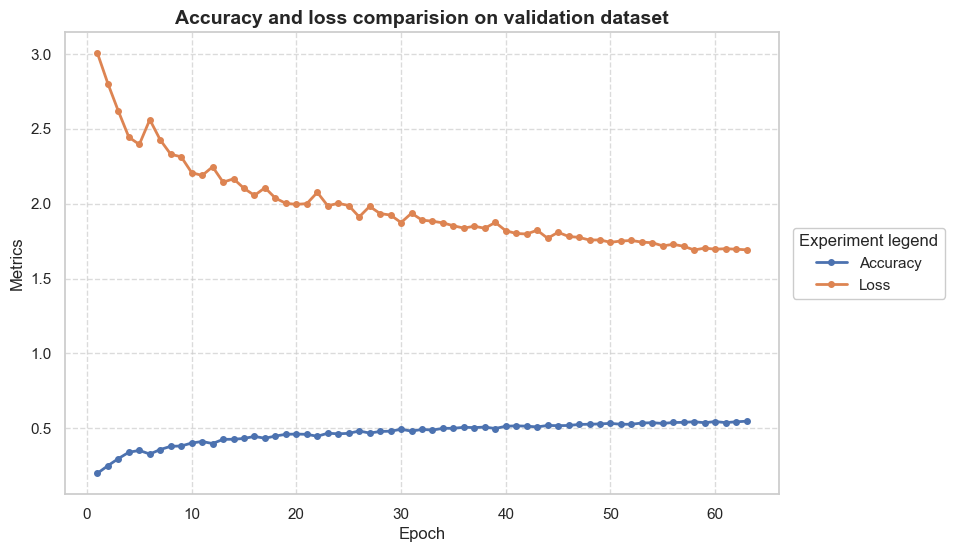

In [11]:
plot_comparison(acc, loss, "Accuracy and loss comparision on validation dataset")

### 4. Etap Test

In [12]:
from helpers import calc_accuracy


preds_l = []
targets_l = []

net.eval()

with torch.inference_mode():    # similar as torch.no_grad()
    for X, y in tqdm(dataloaders['test']):
        X, y = X.to(device), y.to(device)
        logits = net(X)
        _, preds = torch.max(logits, dim=1)
        
        preds_l.append(preds.cpu())
        targets_l.append(y.cpu())

all_preds = torch.cat(preds_l, dim=0)
all_targets = torch.cat(targets_l, dim=0)

#########################################################################################

predictions = all_preds.numpy()
labels = all_targets.numpy()

print(f"Final multiclass test accuracy (from helpers module): {calc_accuracy(predictions, labels)}")

100%|██████████| 35/35 [00:26<00:00,  1.31it/s]

Final multiclass test accuracy (from helpers module): 0.5547220784713358


### 5. Wczytanie danych testowych (do oceny)

In [13]:
# transformacja dla testowego (bez augmentacji)
test_transform = transforms.Compose([
    # transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


class CustomTestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if os.path.isfile(os.path.join(root_dir, f))]

    def __len__(self):
        return len(self.image_files)

    # zwracamy obraz i nazwe
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, img_name


try:
    testset = CustomTestDataset(root_dir="test/", transform=test_transform)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    print(f"Loaded test dataset: {len(testset)} images.")
except FileNotFoundError:
    print("Couldnt fing 'test/' directory!!!!")

Loaded test dataset: 10000 images.


### 6. Generowanie predykcji do preds.csv

In [14]:
def generate_predictions(model, dataloader, device, output_filename="pred.csv"):

    model.eval() 
    predictions_list = []
    
    print(f"Generating preds to {output_filename}...")
    
    with torch.no_grad(): 
        for images, filenames in dataloader:
            images = images.to(device)
            
            outputs = model(images)

            _, predicted_classes = torch.max(outputs, 1) # pobranie indeksu klasy z najwyzszym p-nstwem, redukcja wymiaru z p-nstwem klas
            predicted_classes = predicted_classes.cpu().numpy() # wyniki -> cpu 
            

            for filename, pred in zip(filenames, predicted_classes):
                predictions_list.append([filename, pred])
                
                
    df = pd.DataFrame(predictions_list)
    df.to_csv(output_filename, index=False, header=False)
    print(f"Done!! Saved {len(predictions_list)} predictions.")


generate_predictions(net, testloader, device, "pred.csv")

Generating preds to pred.csv...
Done!! Saved 10000 predictions.
